In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
data = pd.read_csv('Cardiovascular_Disease_Dataset.csv')

In [19]:
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [20]:
x  = data.drop("target",axis=1)
y = data["target"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score

In [35]:
log_r = LogisticRegression(max_iter=1000)
log_r.fit(x_train,y_train)

y_pred_lr = log_r.predict(x_test)

print("logistic Regression f1_score:",f1_score(y_test,y_pred_lr))
print("logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))

logistic Regression f1_score: 0.9702127659574468
logistic Regression Accuracy: 0.965


In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:",accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.985


In [29]:
from sklearn.svm import SVC

In [30]:
svm = SVC(kernel='rbf')
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.985


In [31]:
from sklearn.metrics import confusion_matrix

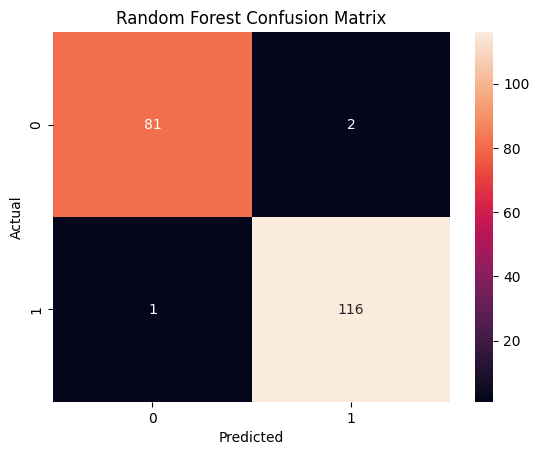

In [32]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()